In [ ]:
# !pip install pennylane koreanize_matplotlib -q

In [4]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# data
# -----------------------------
data = np.array([0.5, 0.75, 0.5])

angles = np.array([
    np.arccos(data[0]),
    np.arccos(data[1]),
    np.pi - np.arccos(data[2])
])

In [5]:
# -----------------------------
# device
# -----------------------------
dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def circuit(angles):

    for i in range(3):
        qml.RY(angles[i], wires=i)

    return [qml.probs(wires=i) for i in range(3)]

probs = circuit(angles)

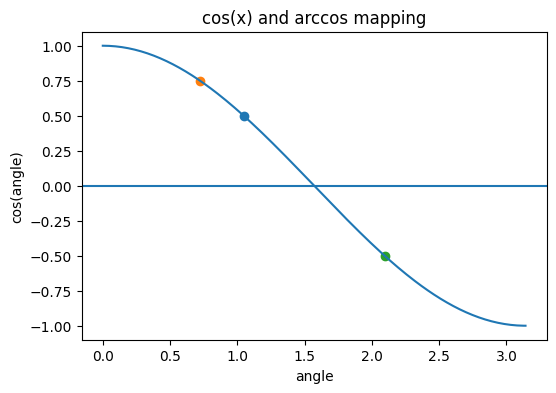

In [6]:
# =========================================================
# Plot 1 : cosine curve + arccos point
# =========================================================

x = np.linspace(0, np.pi, 200)
y = np.cos(x)

plt.figure(figsize=(6,4))
plt.plot(x, y)

plt.scatter(np.arccos(0.5),0.5)
plt.scatter(np.arccos(0.75),0.75)
plt.scatter(np.pi-np.arccos(0.5),-0.5)

plt.axhline(0)
plt.title("cos(x) and arccos mapping")
plt.xlabel("angle")
plt.ylabel("cos(angle)")
plt.show()

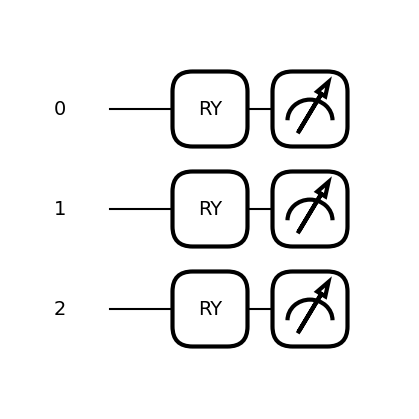

In [8]:
# =========================================================
# Plot 2 : quantum circuit diagram
# =========================================================

fig, ax = qml.draw_mpl(circuit)(angles)
plt.show()

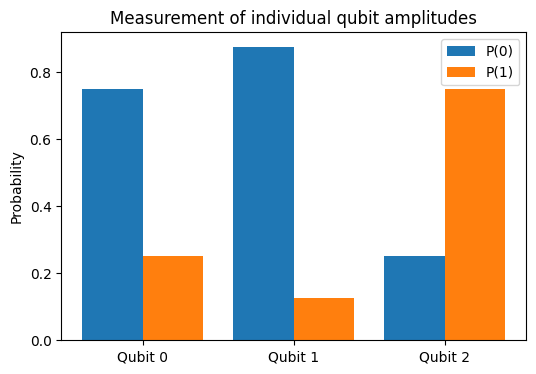

In [7]:
# =========================================================
# Plot 3 : qubit measurement probabilities
# =========================================================

p0 = [p[0] for p in probs]
p1 = [p[1] for p in probs]

x = np.arange(3)

plt.figure(figsize=(6,4))
plt.bar(x-0.2, p0, width=0.4)
plt.bar(x+0.2, p1, width=0.4)

plt.xticks(x, ["Qubit 0","Qubit 1","Qubit 2"])
plt.ylabel("Probability")
plt.title("Measurement of individual qubit amplitudes")
plt.legend(["P(0)","P(1)"])

plt.show()